In [2]:
from diffractio import degrees , mm , um
from diffractio.scalar_masks_X import Scalar_mask_X
from diffractio.scalar_sources_X import Scalar_source_X
from diffractio.utils_drawing import draw_several_fields
from numpy import loadtxt
import numpy as np
import matplotlib.pyplot as plt

## Single slit

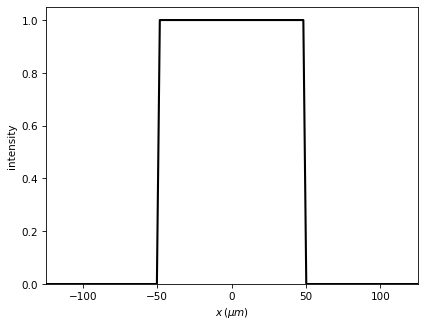

In [3]:
num_data = 128
length = 250 * um
x = np.linspace(-length/2 , length/2, num_data)
wavelength = 0.6328 * um

t1 = Scalar_mask_X(x,wavelength)
t1.slit(x0=0,size=100*um)
t1.draw()
plt.show()

## Double slit

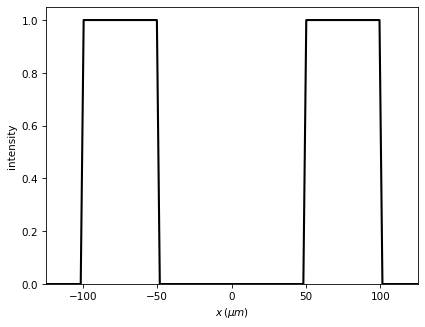

In [4]:
t1 = Scalar_mask_X(x , wavelength)
t1.double_slit(x0=0,size=50*um,separation=150*um)
t1.draw()
plt.show()

## 1D diffraction by a single slit

In [5]:
from diffractio import degrees , mm , um
from diffractio.scalar_masks_X import Scalar_mask_X
from diffractio.scalar_sources_X import Scalar_source_X
from diffractio.utils_drawing import draw_several_fields
import numpy as np
import matplotlib.pyplot as plt

Good result: factor 833.91
Good result: factor 3479.13


(0.0, 6881.7)

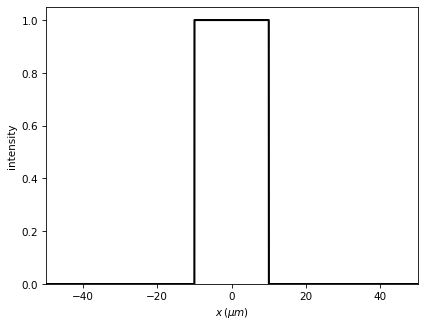

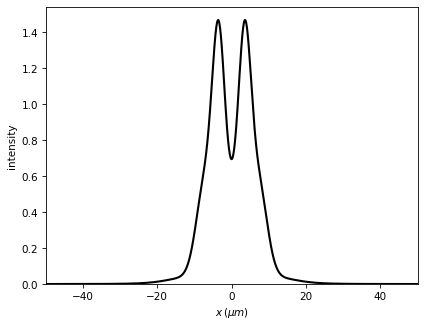

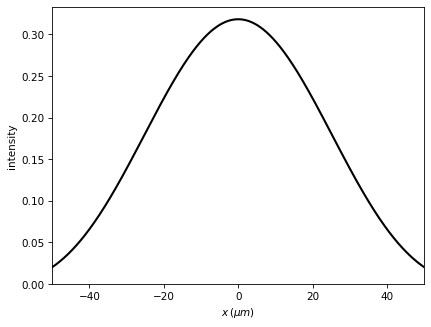

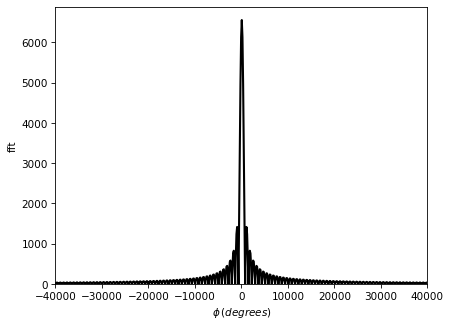

In [6]:
x0 = np.linspace(-50*um , 50*um , 1024*32)
wavelength = 5 * um

# Plane wave
u0 = Scalar_source_X(x=x0,wavelength=wavelength)
u0.plane_wave(A=1,theta=0)

# Slit
t0 = Scalar_mask_X(x=x0,wavelength=wavelength)
t0.slit(x0=0,size=20*um)
t0.draw()
u1 = u0 * t0

#Propagation a certain distance and draw
u2 = u1.RS(z=10*um,new_field=True,verbose=True)
u2.draw(kind='intensity')

u3 = u1.RS(z=250 * um, new_field=True, verbose=True)
u3.draw(kind='intensity')

u5 = u1.fft(z=0.05 * mm, remove0=False, new_field=True)
u5.draw(kind='fft', logarithm=False, normalize=True)
plt.xlim(-40000, 40000)
plt.ylim(bottom=0)

(0.0, 3441.9)

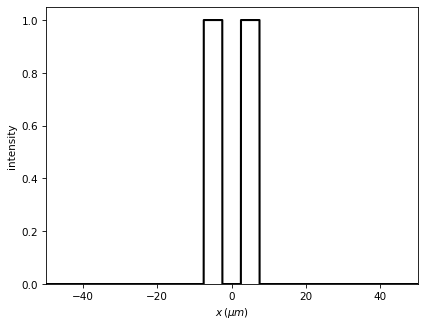

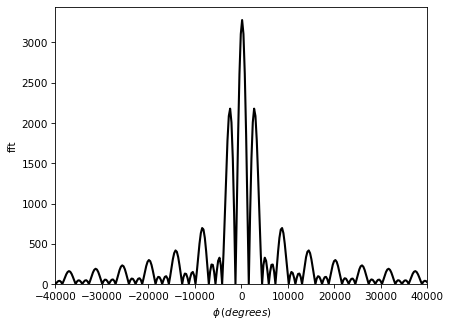

In [7]:
t1 = Scalar_mask_X(x=x0 , wavelength=wavelength)
t1.double_slit(x0=0 , size=5*um,separation=10*um)
t1.draw()

U = t1*u0 
U = U.fft(z=100*um , remove0=False , new_field=True)
U.draw(kind='fft', logarithm=False,normalize=True)
plt.xlim(-40000, 40000)
plt.ylim(bottom=0)

## XY 2D diffraction patterns

(-20.0, 20.0)

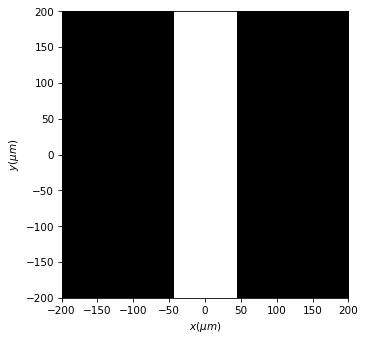

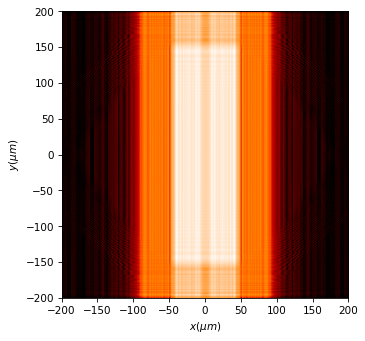

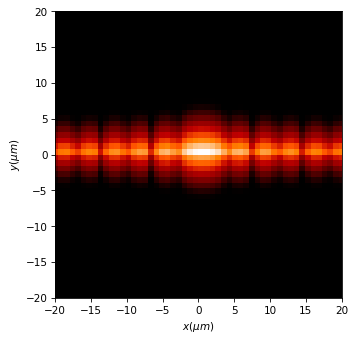

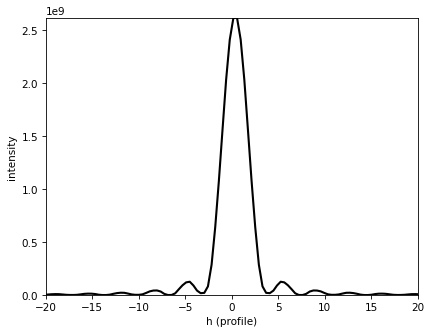

In [16]:
from diffractio.scalar_sources_XY import Scalar_source_XY
from diffractio.scalar_masks_XY import Scalar_mask_XY
from diffractio.utils_drawing import draw_several_fields
from diffractio import nm

x0 = np.linspace(-200 * um, 200 * um, 512)
y0 = np.linspace(-200 * um, 200 * um, 512)
wavelength = 632.8 * nm

u1 = Scalar_source_XY(x=x0, y=y0, wavelength=wavelength)
u1.plane_wave(A=1)

t1 = Scalar_mask_XY(x=x0, y=y0, wavelength=wavelength)
t1.slit(x0=0, size=90 * um, angle=0 * degrees)

u2 = u1 * t1
u2.draw(kind='intensity')

u3 = u2.RS(z=35 * um, new_field=True)
u3.draw(logarithm=1e3)
u3 = u2.fft(remove0=False, new_field=True)
u3.cut_resample(x_limits='', y_limits='', num_points=[1024, 1024])
u3.draw(logarithm=1)
plt.ylim(-20,20)
plt.xlim(-20,20)
u3.draw_profile(point1=(u3.x[0], 0),
                point2=(u3.x[-1], 0),
                npixels=1024,
                kind='intensity',
                order=1)
plt.xlim(-20, 20)

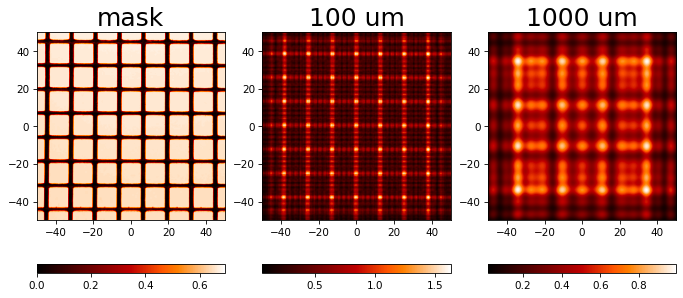

In [5]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

from diffractio import degrees, mm, plt, sp, um, np
from diffractio.scalar_fields_XY import Scalar_field_XY
from diffractio.utils_drawing import draw_several_fields
from diffractio.scalar_masks_XY import Scalar_mask_XY
from diffractio.scalar_sources_XY import Scalar_source_XY

num_pixels = 512

length = 100 * um
x0 = np.linspace(-length / 2, length / 2, num_pixels)
y0 = np.linspace(-length / 2, length / 2, num_pixels)
wavelength = 0.6238 * um

u1 = Scalar_source_XY(x=x0, y=y0, wavelength=wavelength)
u1.plane_wave(A=1, theta=0 * degrees, phi=0 * degrees)

t1 = Scalar_mask_XY(x=x0, y=y0, wavelength=wavelength)

t1.image(filename="TargetMesh2.jpeg", invert=False)
u2 = u1 * t1

u3 = u2.RS(z=50 * um, new_field=True)

u4 = u2.RS(z=900 * um, new_field=True)

draw_several_fields((u2, u3, u4), titles=('mask', '100 um', '1000 um'), logarithm=True)

(-10.0, 10.0)

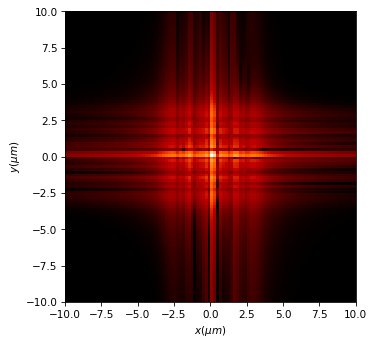

In [9]:
U = u4.fft(remove0=False,new_field=True)
U.cut_resample(x_limits='', y_limits='', num_points=[1024, 1024])
U.draw(logarithm=1)
plt.ylim(-20,20)
plt.xlim(-20,20)